In [31]:
from pathlib import Path
from time import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, imshow, show
from scipy.fftpack import fft2, fftshift, ifft2
from scipy.ndimage import convolve
from skimage.color import rgb2gray
from skimage.io import imread


# Week 4: Fourier transform: filtering and sampling

The exercise of this week is about Fourier Transform, image filtering and sampling. 
Run this notebook on Colab [following this link.](https://colab.research.google.com/github/tavisualcomputing/viscomp2024/blob/main/Exercises/W4/W4_exercise.ipynb)

First load the following libraries that will be necessary.

Load the two images wall.jpg and sidewalk.jpg.

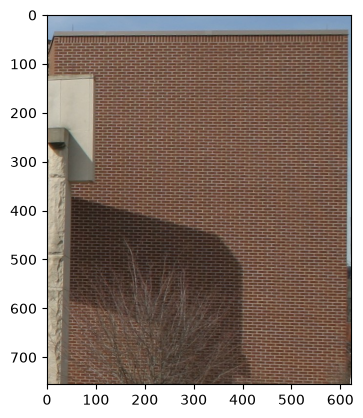

In [32]:
wall = imread('wall.jpg') / 255.
wall_gray = rgb2gray(wall)
imshow(wall)
show()

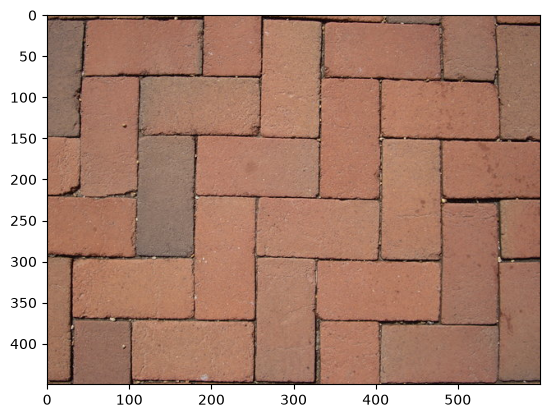

In [33]:
side = imread('sidewalk.jpg') / 255.
side_gray = rgb2gray(side)
imshow(side)
show()

Preliminary question: which of the two images has the most low pass content? Which one has the most high pass content?

Answer: <br>
*The wall picture has the most low pass content, whereas the sidewalk has the most high-pass content*

The following functions will be useful in the course of this tutorial: `fft2`, `ifft2`, `convolve` from scipy and the following function:

In [34]:
def gaussian_filter(shape, sigma):
    """
    Returns a 2D gaussian filter specified by its shape and standard deviation.
    """
    m, n = [(ss - 1.) / 2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x * x + y * y) / (2. * sigma * sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

## Part A: Filtering

Create three Gaussian filters:
- one 5x5 Gaussian low pass filter with standard deviation 1
- one 15x15 Gaussian high pass filter with standard deviation $\sigma=3.5$. Hint: the high pass content of an image can be extracted by subtracting the low pass filtered image from the original image. Hence, you can get a high pass filter kernel from a low pass one by subtracting the low pass filter kernel from a unit impulse filter. A unit impulse filter is a filter full of 0s with a single 1 in the middle, that once convolved with an image returns the same image.
- one band pass filter. To do this, create first a 15x15 Gaussian filter with standard deviation 1 and then convolve this low pass filter with the previous high pass filter to create the band pass filter. Indeed, convolution is associative: 
$$
I \ast F_\text{band-pass} = (I \ast F_\text{low-pass}) \ast F_\text{high-pass} = I \ast (F_\text{low-pass} \ast F_\text{high-pass})
$$

You can then visualize your filters in spatial and frequency domains (using `fft2` and `fftshift` from scipy for the latter). Since the filters are complex in the frequency domain, use `np.abs()` to display the magnitude of the filter.

In [35]:
# Low pass filter
# Enter your code here
lp_filter = gaussian_filter((5, 5), 1)

# High pass filter
# Enter your code here
impulse_kernel = np.zeros((15, 15))
impulse_kernel[7, 7] = 1
hp_gaussian = gaussian_filter((15, 15), 3.5)
hp_filter = impulse_kernel - hp_gaussian

# Band pass filter
# Enter your code here
bp_gaussian = gaussian_filter((15, 15), 1)
bp_filter = convolve(bp_gaussian, hp_filter)

Apply these three filters to the two sample grayscale images in spatial domain first by convolving the image with the kernel, and in frequency domain secondly by taking the Fourier tranform of both the image and the filter kernel and multiplying them. Compare the runtimes of spatial and frequency domain filtering, using the `time` function of python. Compare the filtering results of two images by visualizing the filtered images in both spatial and frequency domains. Check that your initial guess about the low/high pass content of the images is correct.

### Filtering in spatial domain

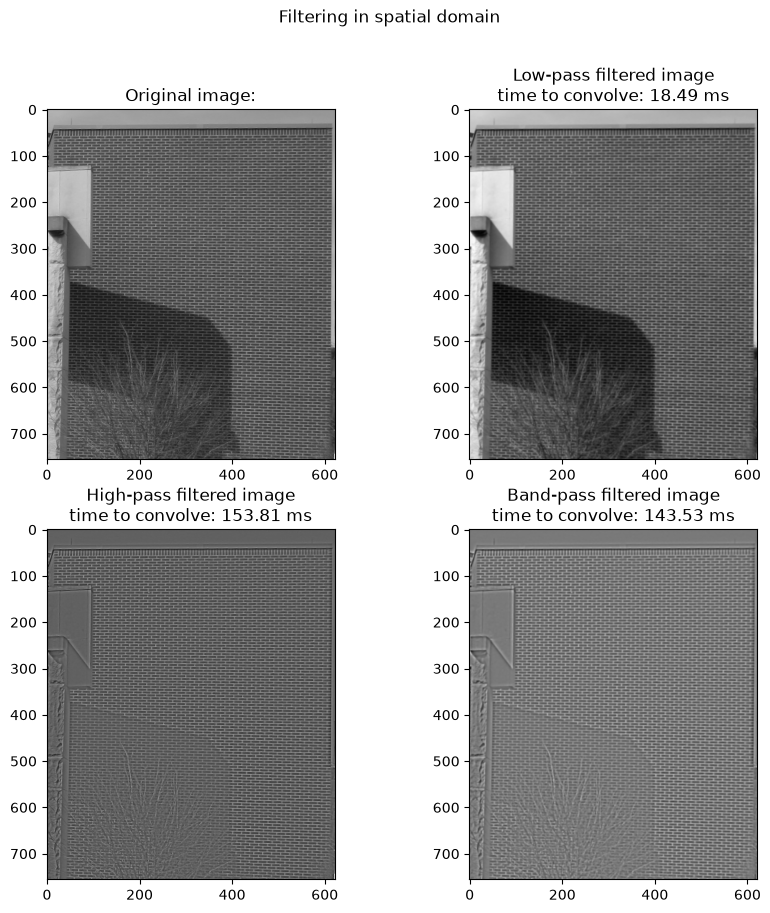

In [36]:
# Enter your code here
lp_start = time()
lp_i = convolve(wall_gray, lp_filter)
lp_time = (time() - lp_start) * 1000

hp_start = time()
hp_i = convolve(wall_gray, hp_filter)
hp_time = (time() - hp_start) * 1000 

bp_start = time()
bp_i = convolve(wall_gray, bp_filter)
bp_time = (time() - bp_start) * 1000

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0,0].imshow(wall_gray, cmap='gray')
axes[0,0].set_title("Original image:")

axes[0,1].imshow(lp_i, cmap='gray')
axes[0,1].set_title(f"Low-pass filtered image\ntime to convolve: {lp_time:.2f} ms")

axes[1,0].imshow(hp_i, cmap='gray')
axes[1,0].set_title(f"High-pass filtered image\ntime to convolve: {hp_time:.2f} ms")

axes[1,1].imshow(bp_i, cmap='gray')
axes[1,1].set_title(f"Band-pass filtered image\ntime to convolve: {bp_time:.2f} ms")

fig.suptitle("Filtering in spatial domain")
plt.show()

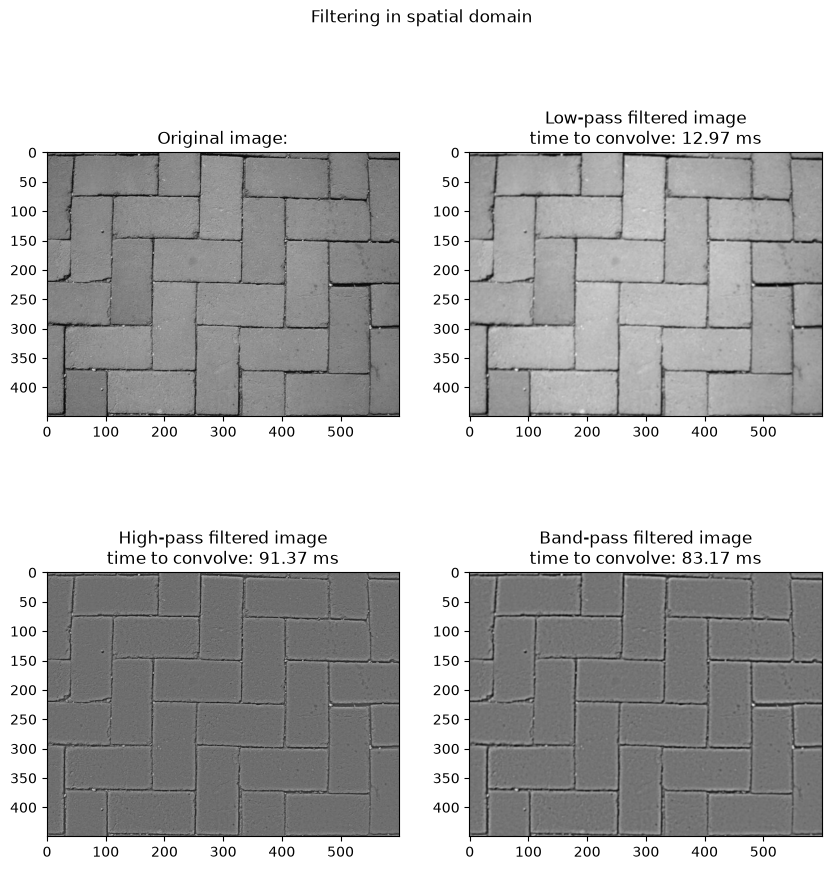

In [37]:
# Enter your code here
lp_start = time()
lp_i = convolve(side_gray, lp_filter)
lp_time = (time() - lp_start) * 1000

hp_start = time()
hp_i = convolve(side_gray, hp_filter)
hp_time = (time() - hp_start) * 1000

bp_start = time()
bp_i = convolve(side_gray, bp_filter)
bp_time = (time() - bp_start) * 1000

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0,0].imshow(side_gray, cmap='gray')
axes[0,0].set_title("Original image:")

axes[0,1].imshow(lp_i, cmap='gray')
axes[0,1].set_title(f"Low-pass filtered image\ntime to convolve: {lp_time:.2f} ms")

axes[1,0].imshow(hp_i, cmap='gray')
axes[1,0].set_title(f"High-pass filtered image\ntime to convolve: {hp_time:.2f} ms")

axes[1,1].imshow(bp_i, cmap='gray')
axes[1,1].set_title(f"Band-pass filtered image\ntime to convolve: {bp_time:.2f} ms")

fig.suptitle("Filtering in spatial domain")
plt.show()


### Filtering in frequency domain

Note: the output of `ifft2` is a numpy array with complex values with zero imaginary part (up to numerical precision). Extract the real component via the `.real` attribute.

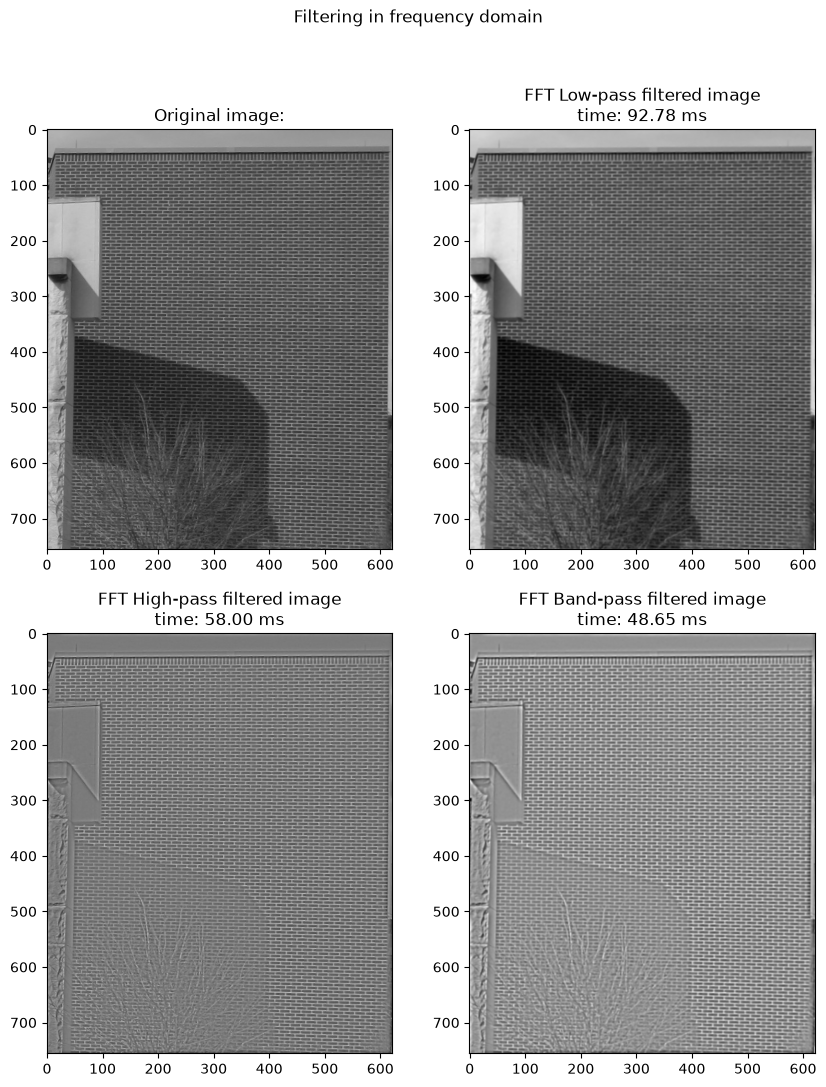

In [38]:
# Enter your code here
start = time()
lp_padded = np.zeros(wall_gray.shape)
lp_padded[:5, :5] = lp_filter
lp_padded = np.roll(lp_padded, shift=(-2, -2), axis=(0, 1))
lp_fft = fft2(lp_padded)
wall_fft = fft2(wall_gray)
l_product = wall_fft * lp_fft
im_l = ifft2(l_product).real
fft_lp_time = (time() - start) * 1000

start = time()
hp_padded = np.zeros(wall_gray.shape)
hp_padded[:15, :15] = hp_filter
hp_padded = np.roll(hp_padded, shift=(-7, -7), axis=(0, 1))
hp_fft = fft2(hp_padded)
h_product = wall_fft * hp_fft
im_h = ifft2(h_product).real
fft_hp_time = (time() - start) * 1000

start = time()
bp_padded = np.zeros(wall_gray.shape)
bp_padded[:15, :15] = bp_filter
bp_padded = np.roll(bp_padded, shift=(-7, -7), axis=(0, 1))
bp_fft = fft2(bp_padded)
b_product = wall_fft * bp_fft
im_b = ifft2(b_product).real
fft_bp_time = (time() - start) * 1000

fig, axes = plt.subplots(2, 2, figsize=(10, 12))

axes[0,0].imshow(wall_gray, cmap='gray')
axes[0,0].set_title("Original image:")

axes[0,1].imshow(im_l, cmap='gray')
axes[0,1].set_title(f"FFT Low-pass filtered image\ntime: {fft_lp_time:.2f} ms")

axes[1,0].imshow(im_h, cmap='gray')
axes[1,0].set_title(f"FFT High-pass filtered image\ntime: {fft_hp_time:.2f} ms")

axes[1,1].imshow(im_b, cmap='gray')
axes[1,1].set_title(f"FFT Band-pass filtered image\ntime: {fft_bp_time:.2f} ms")

fig.suptitle("Filtering in frequency domain")
plt.show()

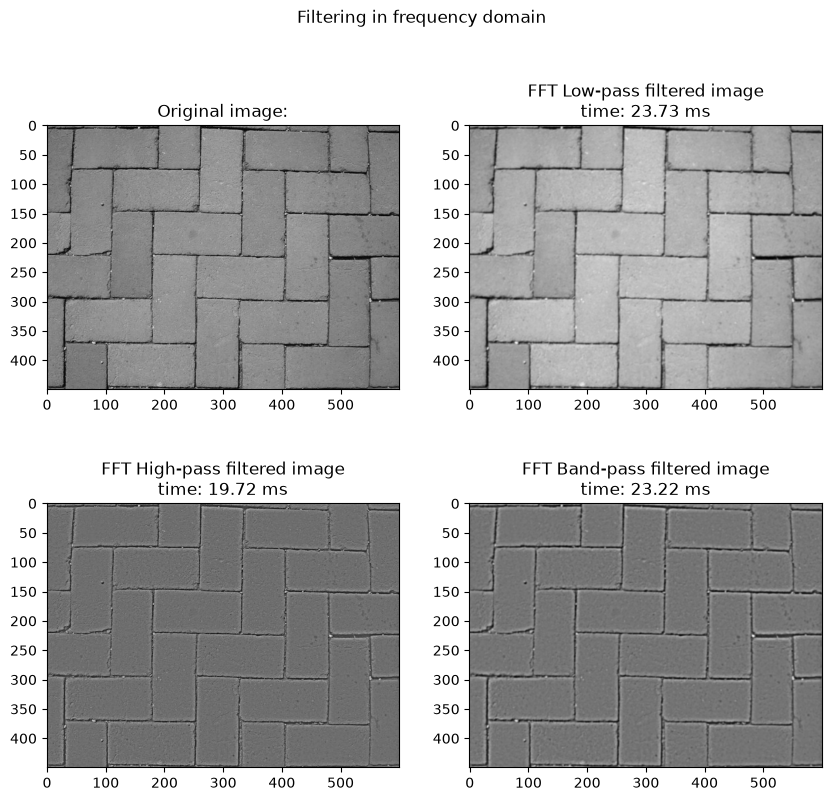

In [39]:
# Enter your code here
start = time()
lp_padded = np.zeros(side_gray.shape)
lp_padded[:5, :5] = lp_filter
lp_padded = np.roll(lp_padded, shift=(-2, -2), axis=(0, 1))
lp_fft = fft2(lp_padded)
side_fft = fft2(side_gray)
l_product = side_fft * lp_fft
im_l = ifft2(l_product).real
fft_lp_time = (time() - start) * 1000

start = time()
hp_padded = np.zeros(side_gray.shape)
hp_padded[:15, :15] = hp_filter
hp_padded = np.roll(hp_padded, shift=(-7, -7), axis=(0, 1))
hp_fft = fft2(hp_padded)
h_product = side_fft * hp_fft
im_h = ifft2(h_product).real
fft_hp_time = (time() - start) * 1000

start = time()
bp_padded = np.zeros(side_gray.shape)
bp_padded[:15, :15] = bp_filter
bp_padded = np.roll(bp_padded, shift=(-7, -7), axis=(0, 1))
bp_fft = fft2(bp_padded)
b_product = side_fft * bp_fft
im_b = ifft2(b_product).real
fft_bp_time = (time() - start) * 1000

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes[0,0].imshow(side_gray, cmap='gray')
axes[0,0].set_title("Original image:")

axes[0,1].imshow(im_l, cmap='gray')
axes[0,1].set_title(f"FFT Low-pass filtered image\ntime: {fft_lp_time:.2f} ms")

axes[1,0].imshow(im_h, cmap='gray')
axes[1,0].set_title(f"FFT High-pass filtered image\ntime: {fft_hp_time:.2f} ms")

axes[1,1].imshow(im_b, cmap='gray')
axes[1,1].set_title(f"FFT Band-pass filtered image\ntime: {fft_bp_time:.2f} ms")

fig.suptitle("Filtering in frequency domain")
plt.show()

## Part B: Sampling

Downsample both images to one fourth of the resolution by taking every second row and column. You can use numpy array slicing for this: `my_array[start:end:step]`. Compare the results in terms of distortions and unexpected effects. Explain why the quality of the two downsampled images differ. 

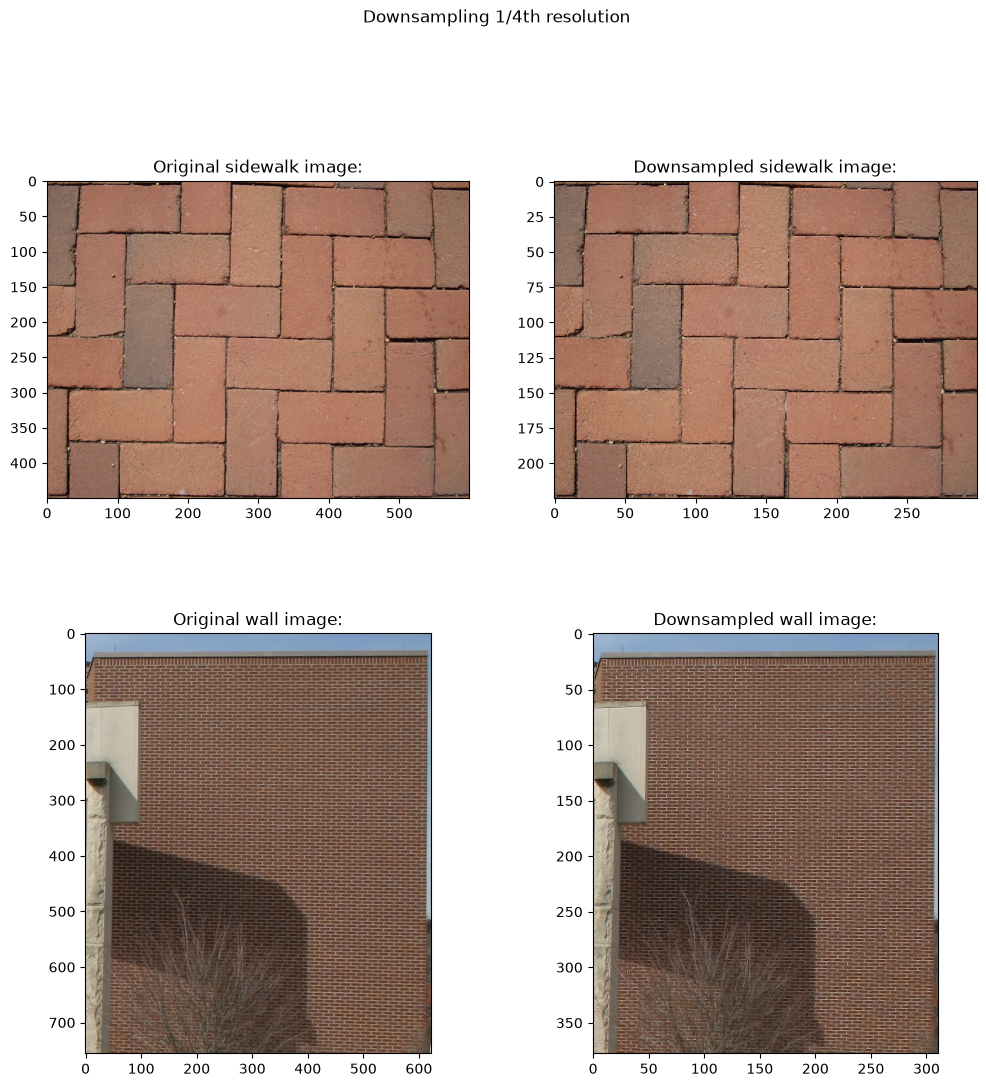

In [40]:
# Enter your code here
sidewalk_ds = side[::2, ::2]
wall_ds = wall[::2, ::2]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].imshow(side)
axes[0,0].set_title("Original sidewalk image:")

axes[0,1].imshow(sidewalk_ds)
axes[0,1].set_title("Downsampled sidewalk image:")

axes[1,0].imshow(wall)
axes[1,0].set_title("Original wall image:")

axes[1,1].imshow(wall_ds)
axes[1,1].set_title("Downsampled wall image:")

fig.suptitle("Downsampling 1/4th resolution")
plt.show()

Create three 15x15 Gaussian low pass filters with standard deviations 0.5, 1 and 1.5 and apply them to the color image wall.jpg. You can filter the three channels separately and gather them in an RGB image with the numpy function `np.stack([r_img, g_img, b_img], axis=-1)`. Downsample the three filtered images to one fourth resolution. Compare the resulting downsampled images in terms of quality.

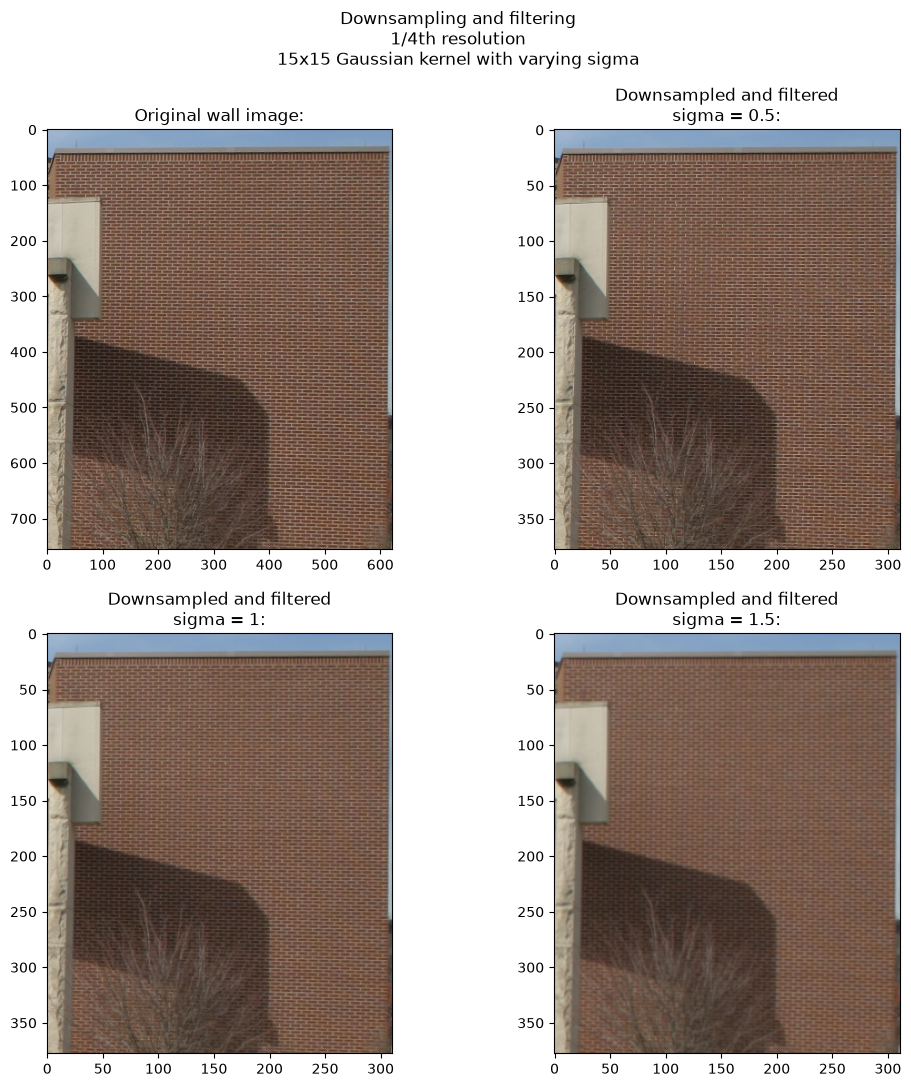

In [48]:
# Create the filters
# Enter your code here
half_gauss = gaussian_filter((15, 15), 0.5)
one_gauss = gaussian_filter((15, 15), 1)
oneandhalf_gauss = gaussian_filter((15, 15), 1.5)

# Convolve them with the RGB image
# Enter your code here
R = wall[:, :, 0]
G = wall[:, :, 1]
B = wall[:, :, 2]
r_filtered05 = convolve(R, half_gauss)
g_filtered05 = convolve(G, half_gauss)
b_filtered05 = convolve(B, half_gauss)
im05 = np.stack([r_filtered05, g_filtered05, b_filtered05], axis = -1)

r_filtered1 = convolve(R, one_gauss)
g_filtered1 = convolve(G, one_gauss)
b_filtered1 = convolve(B, one_gauss)
im1 = np.stack([r_filtered1, g_filtered1, b_filtered1], axis = -1)

r_filtered15 = convolve(R, oneandhalf_gauss)
g_filtered15 = convolve(G, oneandhalf_gauss)
b_filtered15 = convolve(B, oneandhalf_gauss)
im15 = np.stack([r_filtered15, g_filtered15, b_filtered15], axis = -1)

# Downsample the resulting images
# Enter your code here
im05_ds = im05[::2, ::2]
im1_ds = im1[::2, ::2]
im15_ds = im15[::2, ::2]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].imshow(wall)
axes[0,0].set_title("Original wall image:")

axes[0,1].imshow(im05_ds)
axes[0,1].set_title("Downsampled and filtered\nsigma = 0.5:")

axes[1,0].imshow(im1_ds)
axes[1,0].set_title("Downsampled and filtered\nsigma = 1:")

axes[1,1].imshow(im15_ds)
axes[1,1].set_title("Downsampled and filtered\nsigma = 1.5:")

fig.suptitle("Downsampling and filtering\n1/4th resolution\n15x15 Gaussian kernel with varying sigma")
plt.show()


## Bonus: for those that finished earlier

Load the blurred road signs image and using your fresh knowledge about filters, design the perfect filter to make the text readable.

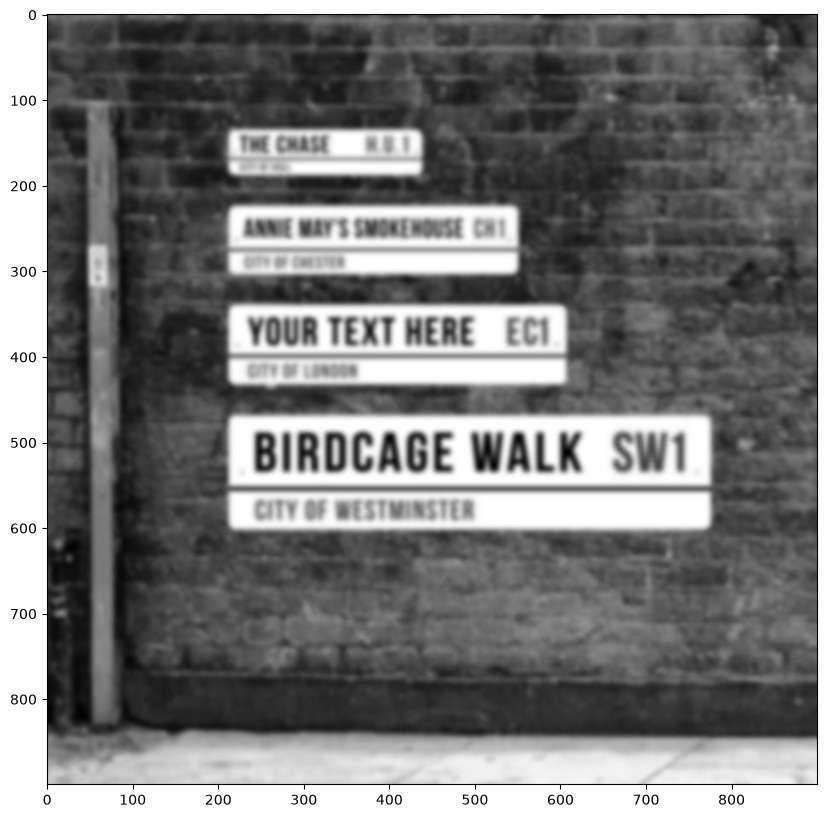

In [42]:
blurred_road_signs = imread('blurred_road_signs.jpg', as_gray=True) / 255.

figure(figsize=(10, 10))
imshow(blurred_road_signs, cmap='gray')
show()

# Exam questions

![alt](exam_questions/Q_B1.png)
![alt](exam_questions/Q_B2_1.png)
![alt](exam_questions/Q_B2_2.png)
![alt](exam_questions/Q_C1.png)
![alt](exam_questions/Q_C2.png)
![alt](exam_questions/Q_C3.png)